# Optimising decay rates

In nctpy's continuous-time model, each node's activity decays back to baseline at a rate set by the diagonal of the
normalised connectome:

$$
A_{\text{norm}} = \frac{A}{\lambda_{\max}(A) + c} - \operatorname{diag}(\text{decay}).
$$

By default every node has the same decay rate, 1 (the familiar $-I$). Kim et al. (*Nat Commun* 2025) instead fit
each node's decay rate to a state transition, so that nodes can differ in how long they sustain activity (their
intrinsic timescales). {func}`~nctpy.optimize.optimize_decay_rates` implements their method: it adjusts the decay
rates by gradient descent so that the optimal trajectory from the initial state $x_0$ to the target state $x_f$
passes close to a reference state at the midpoint of the time horizon, while the system stays stable.

This tutorial fits decay rates for one transition on a synthetic connectome, then shows how to use the result.
It needs PyTorch and the plotting libraries: `pip install "nctpy[optimize,plot]"`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

from nctpy.energies import get_control_inputs, integrate_u
from nctpy.optimize import optimize_decay_rates
from nctpy.plotting import set_plotting_params
from nctpy.utils import convert_states_str2int, matrix_normalization, normalize_state

set_plotting_params()

## A connectome and two brain states

The same synthetic connectome as in {doc}`protocol_workflow`: 100 nodes on a sphere in seven contiguous systems
(A to G), connected more often and more strongly when they are close. Each system defines a binary brain state;
the transition is from system A to system D.

In [2]:
def make_connectome(n_nodes=100, n_systems=7, length=0.5, seed=0):
    rng = np.random.default_rng(seed)
    # node coordinates on a unit sphere, ordered by longitude so that systems are contiguous
    xyz = rng.normal(size=(n_nodes, 3))
    xyz /= np.linalg.norm(xyz, axis=1, keepdims=True)
    xyz = xyz[np.argsort(np.arctan2(xyz[:, 1], xyz[:, 0]))]
    names = [chr(ord("A") + i) for i in range(n_systems)]
    labels = [names[i] for i, nodes in enumerate(np.array_split(np.arange(n_nodes), n_systems)) for _ in nodes]
    # connection probability and weight fall off with distance; within-system pairs are twice as likely
    dist = distance.squareform(distance.pdist(xyz, "euclidean"))
    decay = np.exp(-dist / length)
    p = np.where(np.equal.outer(labels, labels), np.minimum(1, 2 * decay), decay)
    edges = np.triu(rng.random((n_nodes, n_nodes)) < p, k=1)
    weights = rng.lognormal(0, 1, size=(n_nodes, n_nodes)) * decay
    A = np.where(edges, weights, 0)
    return A + A.T, dist, labels


adjacency, _, system_labels = make_connectome()
n_nodes = adjacency.shape[0]

states, state_labels = convert_states_str2int(system_labels)
initial_state = normalize_state(states == state_labels.index("A"))
target_state = normalize_state(states == state_labels.index("D"))
bystanders = np.logical_and(initial_state == 0, target_state == 0)

The method assumes a connectome without self-connections, so that every node starts from the same decay rate.
This one has none; for a connectome that has them, `optimize_decay_rates` removes them by default
(`zero_diagonal=True`).

## Before fitting: uniform decay

With the standard normalisation (decay rate 1 everywhere), compute the optimal trajectory. Kim et al. use the
target state as the reference state of the cost (`xr="xf"`), which is also `optimize_decay_rates`' default; note
that `get_control_inputs` defaults to `xr="zero"`. The quantity the fit will reduce is the distance between the
trajectory at the midpoint, $x(T/2)$, and the reference state.

In [3]:
time_horizon = 1
control_set = np.eye(n_nodes)  # uniform full control set
trajectory_constraints = np.eye(n_nodes)
rho = 1


def transition(A_norm):
    # optimal trajectory and control signals, with the target state as reference
    x, u, err = get_control_inputs(
        A_norm=A_norm, T=time_horizon, B=control_set, x0=initial_state, xf=target_state,
        system="continuous", rho=rho, S=trajectory_constraints, xr="xf",
    )
    midpoint = x.shape[0] // 2  # T/2
    return x, np.sum(integrate_u(u)), np.linalg.norm(x[midpoint] - target_state), err


adjacency_norm = matrix_normalization(A=adjacency, system="continuous", c=1)
x_uniform, energy_uniform, distance_uniform, err = transition(adjacency_norm)
print("energy = {:.2f}; distance at T/2 = {:.3f}; errors = {:.1E}, {:.1E}".format(
    energy_uniform, distance_uniform, *err))

energy = 2550.64; distance at T/2 = 0.639; errors = 9.2E-16, 6.9E-14


## Fitting

`optimize_decay_rates` takes the raw connectome (it normalises it itself) and the two states. Its defaults are
those of Kim et al. (2025): up to 1000 steps of Adam at a learning rate of 0.01, stopping early once the loss and
the largest eigenvalue have stopped changing. Training runs on a GPU when one is available; here it is pinned to
the CPU so that the page is reproducible. Results on different devices agree to floating-point precision.

In [4]:
fit = optimize_decay_rates(adjacency, initial_state, target_state, device="cpu", progress=False)
print(fit.n_steps_run, "steps; stopped early:", fit.stopped_early)

383 steps; stopped early: True


The result is a {class}`~nctpy.optimize.DecayRateFit`. Its training traces show the loss falling while the
largest eigenvalue of the fitted matrix stays negative, i.e. the system stays stable:

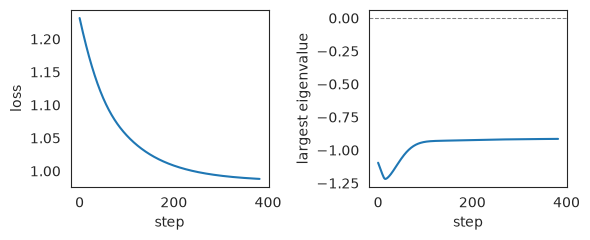

In [5]:
f, ax = plt.subplots(1, 2, figsize=(6, 2.5))
ax[0].plot(fit.loss)
ax[0].set_ylabel("loss")
ax[1].plot(fit.max_eigenvalue)
ax[1].axhline(0, color="gray", linewidth=0.75, linestyle="--")
ax[1].set_ylabel("largest eigenvalue")
for cax in ax:
    cax.set_xlabel("step")
f.tight_layout()
plt.show()

## The fitted decay rates

`fit.decay` holds one decay rate per node. Grouping the nodes by their role in the transition shows what the fit
did in this example: the nodes of the initial state decay fastest, letting their activity fall away quickly, and
the nodes of the target state decay slowest, so their activity is sustained once it arrives.

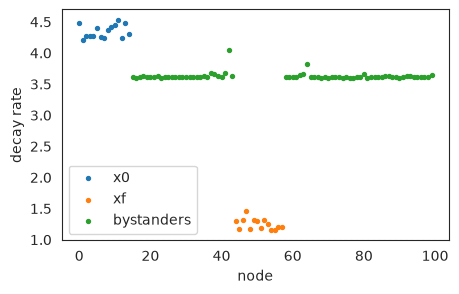

x0: mean decay rate 4.35
xf: mean decay rate 1.25
bystanders: mean decay rate 3.63


In [6]:
groups = {"x0": initial_state != 0, "xf": target_state != 0, "bystanders": bystanders}

f, ax = plt.subplots(1, 1, figsize=(5, 3))
for name, nodes in groups.items():
    ax.scatter(np.flatnonzero(nodes), fit.decay[nodes], s=8, label=name)
ax.axhline(1, color="gray", linewidth=0.75, linestyle="--")  # the uniform decay rate
ax.set_xlabel("node")
ax.set_ylabel("decay rate")
ax.legend()
plt.show()

for name, nodes in groups.items():
    print("{}: mean decay rate {:.2f}".format(name, fit.decay[nodes].mean()))

## Using the fit

`fit.A_norm` is the fitted, normalised connectome, ready for any of nctpy's functions. With it the trajectory
passes closer to the target state at the midpoint, and the transition takes less energy:

energy = 2295.00; distance at T/2 = 0.516; errors = 6.9E-16, 8.1E-14


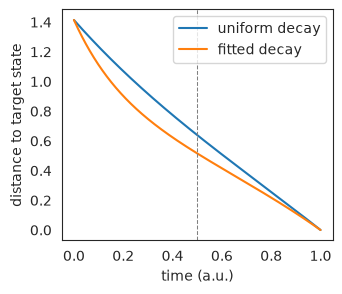

In [7]:
x_fitted, energy_fitted, distance_fitted, err = transition(fit.A_norm)
print("energy = {:.2f}; distance at T/2 = {:.3f}; errors = {:.1E}, {:.1E}".format(
    energy_fitted, distance_fitted, *err))

time = np.linspace(0, time_horizon, x_fitted.shape[0])
f, ax = plt.subplots(1, 1, figsize=(3.5, 3))
ax.plot(time, np.linalg.norm(x_uniform - target_state, axis=1), label="uniform decay")
ax.plot(time, np.linalg.norm(x_fitted - target_state, axis=1), label="fitted decay")
ax.axvline(time_horizon / 2, color="gray", linewidth=0.75, linestyle="--")
ax.set_xlabel("time (a.u.)")
ax.set_ylabel("distance to target state")
ax.legend()
plt.show()

The same matrix can be rebuilt from the decay rates with {func}`~nctpy.utils.matrix_normalization`, whose
`decay` argument takes one rate per node (or a single rate for all):

In [8]:
A_rebuilt = matrix_normalization(A=adjacency, system="continuous", c=1, zero_diagonal=True, decay=fit.decay)
print(np.allclose(A_rebuilt, fit.A_norm))

True


Kim et al. (2025) report fitted values on a different scale: a value $v$ in their Fig. 2B corresponds to a decay
rate of $1 - v$ here.

## Several transitions at once

Passing states as columns, `x0` and `xf` of shape $(N, k)$, fits a single set of decay rates to all $k$
transitions together; the midpoint distance is averaged over them. Here, each system to the system three along:

In [9]:
X0 = np.column_stack([normalize_state(states == i) for i in range(len(state_labels))])
XF = np.column_stack([normalize_state(states == (i + 3) % len(state_labels)) for i in range(len(state_labels))])
fit_joint = optimize_decay_rates(adjacency, X0, XF, device="cpu", progress=False)
print(X0.shape, fit_joint.decay.shape)

(100, 7) (100,)


## Options

- `xr` sets the reference state, both in the cost and as the midpoint target: the target state (default), the
  initial state, zero, the midpoint between the two, or any state you pass.
- `B`, `S` and `rho` set the control set, the trajectory constraints and their relative weight, as in
  {func}`~nctpy.energies.get_control_inputs`.
- `eigenvalues="general"` computes the stability penalty from the eigenvalues of the matrix as it is, which is
  exact for directed connectomes too. The default, `"symmetric"`, reproduces Kim et al.'s computation and is exact
  for undirected connectomes such as this one.

See {func}`~nctpy.optimize.optimize_decay_rates` for every parameter.